In [18]:
import pandas as pd
po_df = pd.read_csv(r'C:\Users\N.Abhishek\purchase_orders_large.csv')
po_df.head(10)

,po_id,vendor_name,category,po_amount,delivery_status,order_date
0,1001,MetroSupplies,IT Hardware,30328,Late,2026-03-14
1,1002,FastLogistics,IT Hardware,71942,On Time,2026-05-23
2,1003,OceanFreight,IT Hardware,42306,Late,2026-05-29
3,1004,PrimeMaterials,Packaging,54915,On Time,2026-06-12
4,1005,MetroSupplies,IT Hardware,52219,Late,2026-03-07
5,1006,Zenith Components,Electronics,95879,On Time,2026-04-01
6,1007,TechSource Ltd,Logistics,79644,On Time,2026-05-10
7,1008,MetroSupplies,Logistics,75279,Late,2026-06-12
8,1009,OceanFreight,IT Hardware,68028,On Time,2026-01-20
9,1010,PrimeMaterials,Packaging,15126,Late,2026-01-10


In [42]:
vendor_scorecard = (
    po_df.groupby('vendor_name')
    .agg(
        total_spend=('po_amount', 'sum'),
        total_orders=('po_id', 'count'),
        on_time_orders=(
            'delivery_status',
            lambda x: (x == 'On Time').sum(),
        ),
    )
    .reset_index()
)
vendor_scorecard['on_time_percentage'] = (vendor_scorecard['on_time_orders']
                                           /vendor_scorecard['total_orders']*100).round(2)
vendor_scorecard = vendor_scorecard.sort_values(by = 'total_spend', ascending = False)
vendor_scorecard


,vendor_name,total_spend,total_orders,on_time_orders,on_time_percentage
0,Acme Supplies,3901737,62,50,80.65
4,MetroSupplies,3238904,55,34,61.82
8,TechSource Ltd,3208965,57,46,80.70
5,OceanFreight,3161411,51,36,70.59
6,PrimeMaterials,2899237,49,37,75.51
9,Zenith Components,2804580,54,40,74.07
2,FastLogistics,2649114,48,31,64.58
3,Global Parts Co,2421653,41,33,80.49
7,Summit Materials,2327460,44,36,81.82
1,BrightTech,2280148,39,34,87.18


In [47]:
# Task 1: Add on_time_pct
vendor_scorecard['on_time_pct'] = (
    vendor_scorecard['on_time_orders'] / vendor_scorecard['total_orders'] * 100
).round(1)

# Task 2: Add performance_flag
vendor_scorecard['performance_flag'] = 'Good'
vendor_scorecard.loc[
    vendor_scorecard['on_time_pct'] < 80, 'performance_flag'
] = 'Needs Improvement'
vendor_scorecard

,vendor_name,total_spend,total_orders,on_time_orders,on_time_percentage,on_time_pct,performance_flag
0,Acme Supplies,3901737,62,50,80.65,80.6,Good
4,MetroSupplies,3238904,55,34,61.82,61.8,Needs Improvement
8,TechSource Ltd,3208965,57,46,80.70,80.7,Good
5,OceanFreight,3161411,51,36,70.59,70.6,Needs Improvement
6,PrimeMaterials,2899237,49,37,75.51,75.5,Needs Improvement
9,Zenith Components,2804580,54,40,74.07,74.1,Needs Improvement
2,FastLogistics,2649114,48,31,64.58,64.6,Needs Improvement
3,Global Parts Co,2421653,41,33,80.49,80.5,Good
7,Summit Materials,2327460,44,36,81.82,81.8,Good
1,BrightTech,2280148,39,34,87.18,87.2,Good


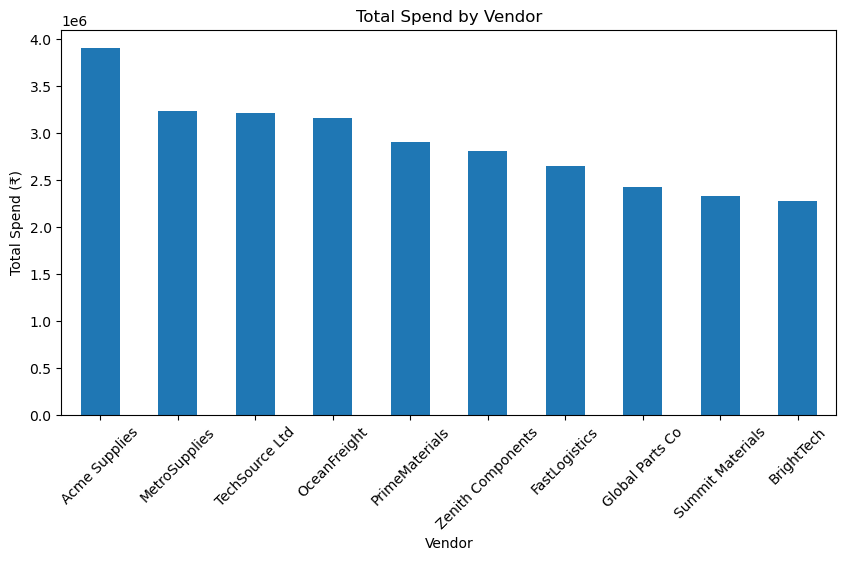

In [49]:
import matplotlib.pyplot as plt
vendor_scorecard.set_index('vendor_name')['total_spend'].plot(kind='bar', figsize=(10,5))
plt.title('Total Spend by Vendor')
plt.xlabel('Vendor')
plt.ylabel('Total Spend (₹)')
plt.xticks(rotation=45)
plt.show()

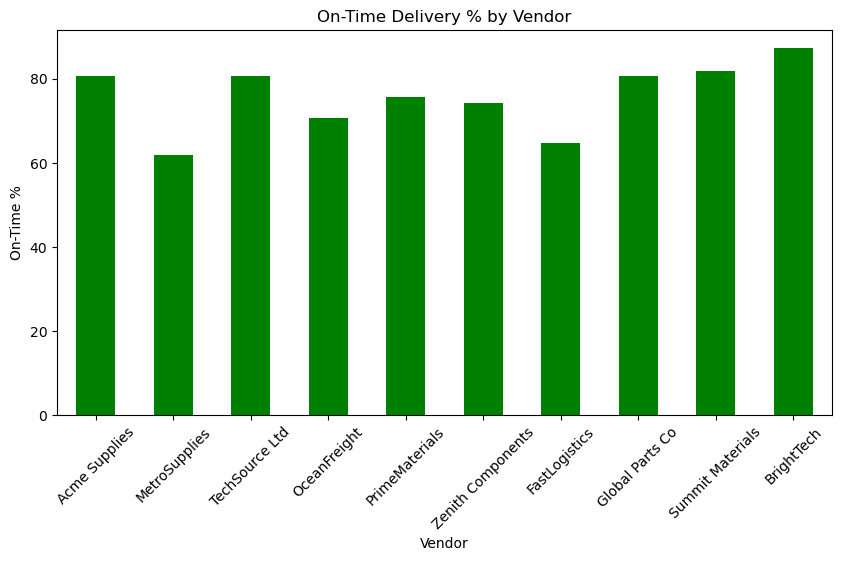

In [50]:
vendor_scorecard.set_index('vendor_name')['on_time_pct'].plot(kind='bar', color='green', figsize=(10,5))
plt.title('On-Time Delivery % by Vendor')
plt.xlabel('Vendor')
plt.ylabel('On-Time %')
plt.xticks(rotation=45)
plt.show()